In [1]:
import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import poisson

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"

ENERGIES = [40, 60, 80]
THICKNESSES = ["0p5mm", "1mm", "2mm"]
THICK_LABELS = {"0p5mm": "0.5mm", "1mm": "1mm", "2mm": "2mm"}
N_BASELINE = 10000
ROI_FRACTION = 0.01  # assumed contaminant footprint as fraction of image — ADJUST per real fragment size

print("Setup complete.")

Setup complete.


In [2]:
def trapezoid_area(y, x):
    """Manual trapezoidal integration — works on any numpy version (avoids np.trapz deprecation)."""
    y = np.asarray(y)
    x = np.asarray(x)
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2.0)

def load_hits_and_spectrum(path):
    f = uproot.open(path)
    pc = f[f"DetectorHistogrammer/{DET}/charge/pixel_charge;1"].to_numpy()
    cc = f[f"DetectorHistogrammer/{DET}/charge/cluster_charge;1"].to_numpy()
    hits = int(pc[0].sum())
    return hits, pc, cc

def bhattacharyya(hist1, hist2):
    p = hist1 / (hist1.sum() + 1e-12)
    q = hist2 / (hist2.sum() + 1e-12)
    bc = np.sum(np.sqrt(p * q))
    bc = min(bc, 1.0)
    return -np.log(bc + 1e-12)

print("Helper functions defined.")

Helper functions defined.


In [3]:
background = {}
for E in ENERGIES:
    path = os.path.join(BASE, f"s1_cdte_{E}keV.root")
    hits, pc, cc = load_hits_and_spectrum(path)
    background[E] = {"hits": hits, "pixel_charge": pc, "cluster_charge": cc}
    print(f"  {E} keV background: {hits:,} hits")

  40 keV background: 16,547 hits
  60 keV background: 12,554 hits
  80 keV background: 7,786 hits


In [4]:
contaminant = {}
for E in ENERGIES:
    for T in THICKNESSES:
        path = os.path.join(BASE, f"food_contam_{E}keV_{T}.root")
        if not os.path.exists(path):
            print(f"  MISSING: food_contam_{E}keV_{T}.root")
            continue
        hits, pc, cc = load_hits_and_spectrum(path)
        contaminant[(E, T)] = {"hits": hits, "pixel_charge": pc, "cluster_charge": cc}
        print(f"  {E} keV / {T}: {hits:,} hits")

  40 keV / 0p5mm: 3,982 hits
  40 keV / 1mm: 966 hits
  40 keV / 2mm: 50 hits
  60 keV / 0p5mm: 7,768 hits
  60 keV / 1mm: 4,786 hits
  60 keV / 2mm: 1,865 hits
  80 keV / 0p5mm: 6,140 hits
  80 keV / 1mm: 4,865 hits
  80 keV / 2mm: 3,044 hits


In [13]:
def get_cluster_count(path):
    """Total number of distinct photon clusters - the correct unit for
    Poisson statistics, unlike raw pixel hits which over-count due to
    multi-pixel clusters from a single photon."""
    f = uproot.open(path)
    cs = f[f"DetectorHistogrammer/{DET}/cluster_size/cluster_size;1"].to_numpy()
    cc = f[f"DetectorHistogrammer/{DET}/charge/cluster_charge;1"].to_numpy()
    return int(cs[0].sum()), cc

# Reload background and contaminant using CLUSTER count (correct photon-equivalent N)
background_clusters = {}
for E in ENERGIES:
    path = os.path.join(BASE, f"s1_cdte_{E}keV.root")
    clusters, cc = get_cluster_count(path)
    background_clusters[E] = {"clusters": clusters, "cluster_charge": cc}
    print(f"  {E} keV background: {clusters:,} clusters (vs {background[E]['hits']:,} raw pixel hits)")

contaminant_clusters = {}
for E in ENERGIES:
    for T in THICKNESSES:
        path = os.path.join(BASE, f"food_contam_{E}keV_{T}.root")
        if not os.path.exists(path):
            continue
        clusters, cc = get_cluster_count(path)
        contaminant_clusters[(E, T)] = {"clusters": clusters, "cluster_charge": cc}

results = []
results = []
for E in ENERGIES:
    bg_n = background_clusters[E]["clusters"]
    bg_cc = background_clusters[E]["cluster_charge"]
    for T in THICKNESSES:
        if (E, T) not in contaminant_clusters:
            continue
        c_n = contaminant_clusters[(E, T)]["clusters"]
        c_cc = contaminant_clusters[(E, T)]["cluster_charge"]

        # ROI-scaled means - CNR/SNR must use the SAME region size as Pd/FPR
        # otherwise comparing whole-image statistics overstates detectability
        mean_bg_roi = bg_n * ROI_FRACTION
        mean_c_roi = c_n * ROI_FRACTION
        sigma_bg_roi = np.sqrt(max(mean_bg_roi, 1e-9))
        sigma_c_roi = np.sqrt(max(mean_c_roi, 1e-9))

        cnr = abs(mean_bg_roi - mean_c_roi) / np.sqrt((sigma_bg_roi**2 + sigma_c_roi**2) / 2)
        snr_bg = mean_bg_roi / sigma_bg_roi
        snr_c = mean_c_roi / sigma_c_roi

        bd = bhattacharyya(bg_cc[0], c_cc[0])

        thresholds = np.linspace(0, mean_bg_roi * 1.5, 200)
        pd_curve = poisson.cdf(thresholds, mean_c_roi)
        fpr_curve = poisson.cdf(thresholds, mean_bg_roi)

        order = np.argsort(fpr_curve)
        auc = trapezoid_area(pd_curve[order], fpr_curve[order])

        idx_5pct = np.argmin(np.abs(fpr_curve - 0.05))
        pd_at_5pct_fpr = pd_curve[idx_5pct]

        results.append({
            "energy": E, "thickness": T, "thickness_label": THICK_LABELS[T],
            "bg_hits": bg_n, "c_hits": c_n,
            "transmission_pct": (c_n / bg_n) * 100 if bg_n else 0,
            "cnr": cnr, "snr_bg": snr_bg, "snr_c": snr_c,
            "bhattacharyya": bd, "auc": auc, "pd_at_5pct_fpr": pd_at_5pct_fpr,
            "fpr_curve": fpr_curve, "pd_curve": pd_curve,
        })

print(f"Computed metrics for {len(results)} combinations (ROI-consistent statistics, ROI_FRACTION={ROI_FRACTION}).")

  40 keV background: 11,290 clusters (vs 16,547 raw pixel hits)
  60 keV background: 8,305 clusters (vs 12,554 raw pixel hits)
  80 keV background: 5,024 clusters (vs 7,786 raw pixel hits)
Computed metrics for 9 combinations (ROI-consistent statistics, ROI_FRACTION=0.01).


In [14]:
import pandas as pd

df = pd.DataFrame(results)
summary_df = df[["energy", "thickness_label", "transmission_pct", "cnr",
                  "snr_bg", "snr_c", "bhattacharyya", "auc", "pd_at_5pct_fpr"]].copy()
summary_df.columns = ["Energy (keV)", "Thickness", "Transmission (%)", "CNR",
                       "SNR (bg)", "SNR (contam)", "Bhattacharyya", "AUC", "Pd @ 5% FPR"]
summary_df = summary_df.round(3)
summary_df

,Energy (keV),Thickness,Transmission (%),CNR,SNR (bg),SNR (contam),Bhattacharyya,AUC,Pd @ 5% FPR
0,40,0.5mm,23.950,10.264,10.625,5.200,0.009,1.000,1.000
1,40,1mm,5.713,13.780,10.625,2.540,0.040,1.000,1.000
2,40,2mm,0.310,14.957,10.625,0.592,0.303,1.000,1.000
3,60,0.5mm,62.179,3.828,9.113,7.186,0.003,0.997,0.988
4,60,1mm,38.579,6.724,9.113,5.660,0.008,1.000,1.000
5,60,2mm,14.979,10.219,9.113,3.527,0.023,1.000,1.000
6,80,0.5mm,79.120,1.564,7.088,6.305,0.003,0.865,0.431
7,80,1mm,62.858,2.917,7.088,5.620,0.007,0.981,0.889
8,80,2mm,39.650,5.119,7.088,4.463,0.020,0.999,1.000


In [15]:
TAU = 120e-9  # seconds, Medipix3 time-to-peak used as dead-time proxy (caveat above)
true_rates = np.logspace(2, 8, 200)  # counts/s/pixel, swept range
m_nonparalyzable = true_rates / (1 + true_rates * TAU)
m_paralyzable = true_rates * np.exp(-true_rates * TAU)
loss_nonparalyzable = 1 - (m_nonparalyzable / true_rates)
loss_paralyzable = 1 - (m_paralyzable / true_rates)

# Datasheet reference: 826 Mcounts/mm²/s -> per-pixel (55um x 55um = 3.025e-5 mm²)
pixel_area_mm2 = 0.055 * 0.055
max_rate_per_pixel = 826e6 * pixel_area_mm2  # counts/s/pixel

print(f"Datasheet max rate converted to per-pixel: {max_rate_per_pixel/1000:.1f} kHz/pixel")

Datasheet max rate converted to per-pixel: 2498.7 kHz/pixel


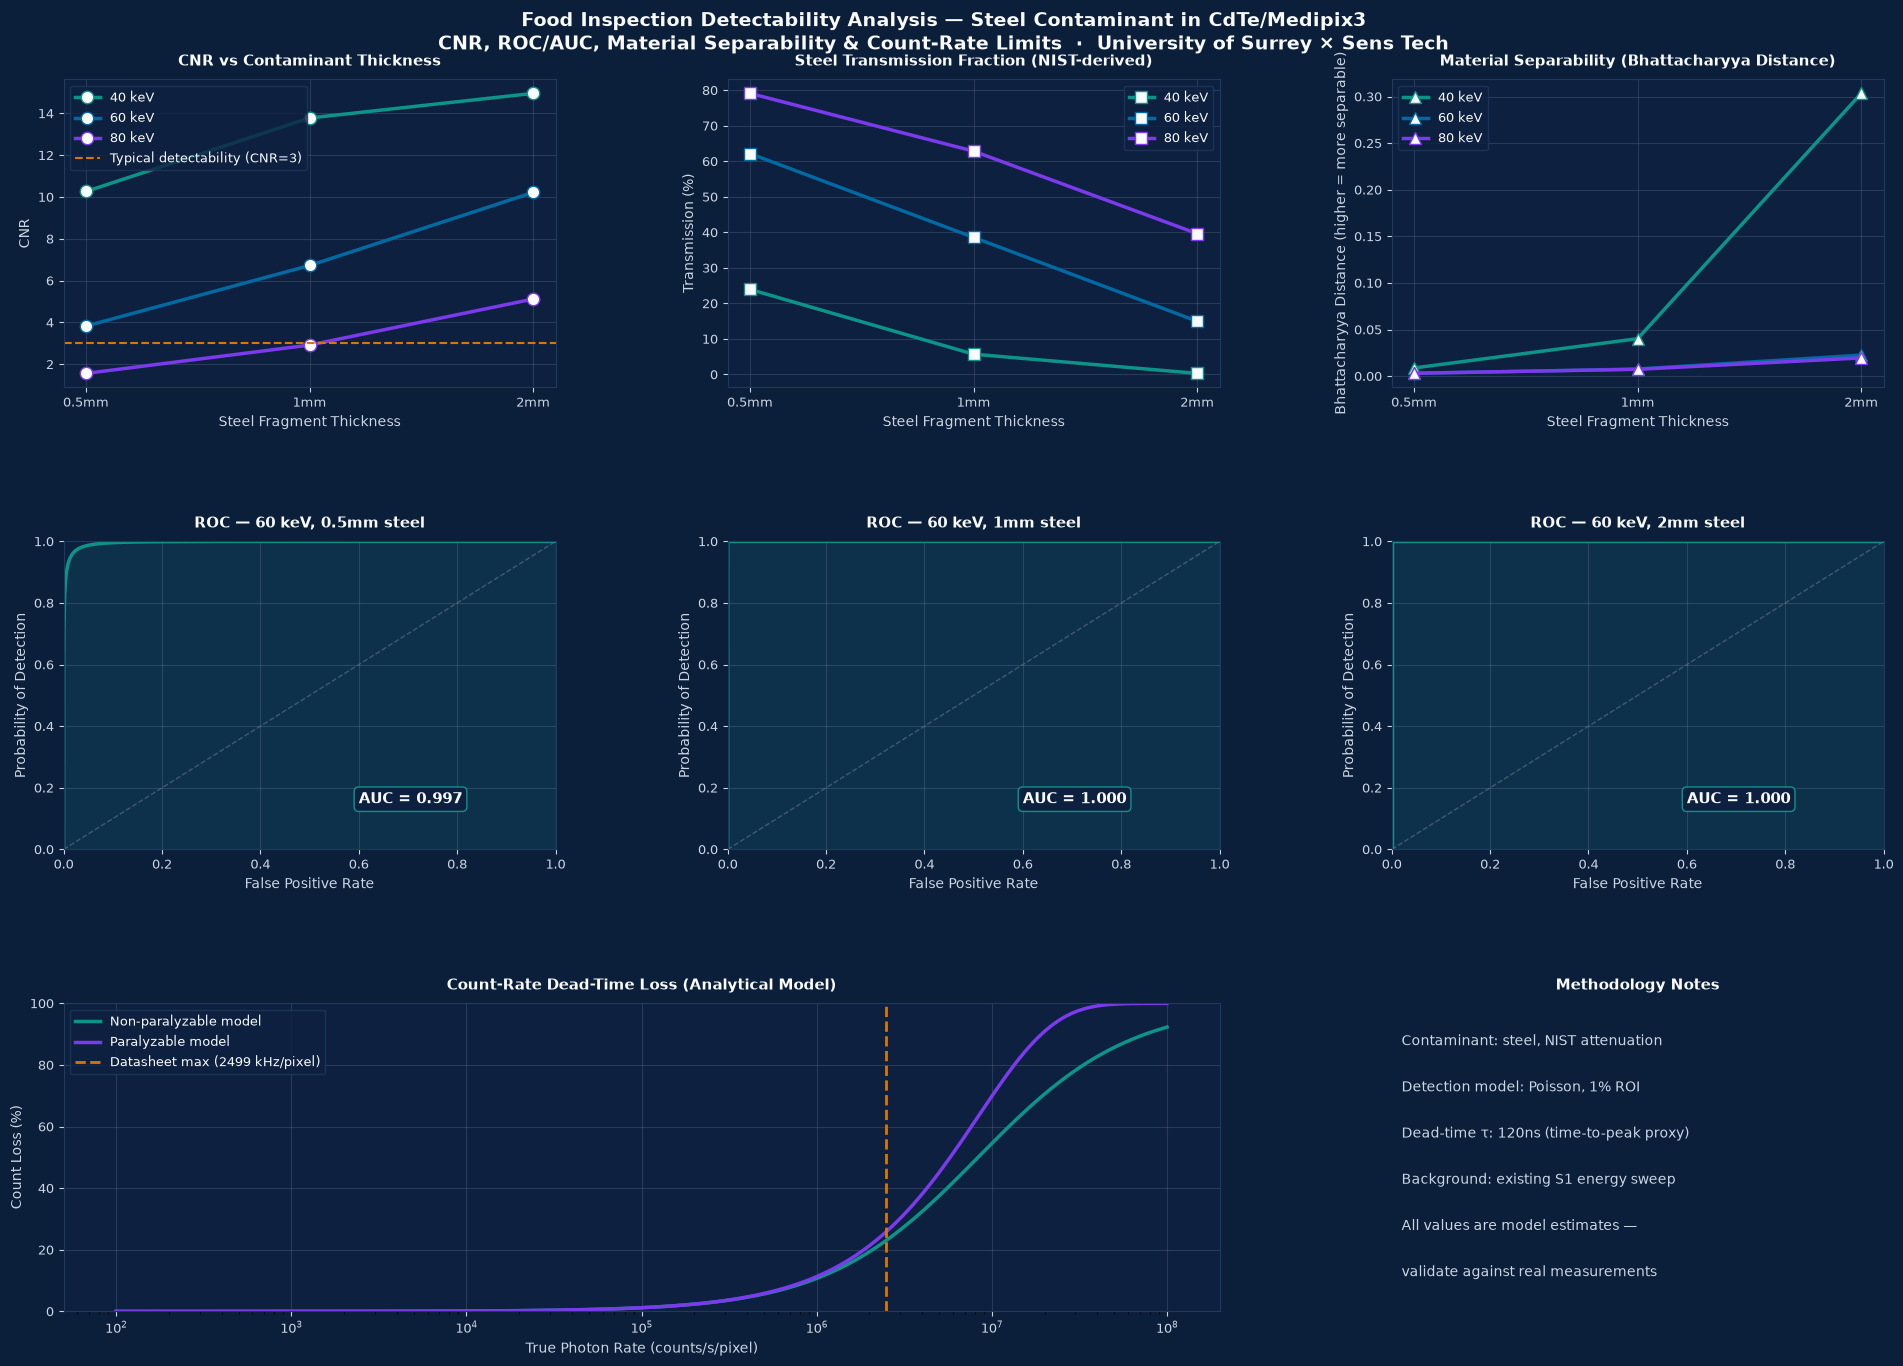


Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/food_inspection_dashboard.png


In [16]:
NAVY, WHITE, LGRAY, GRAY = "#0B1F3A", "#F8FAFC", "#CBD5E1", "#64748B"
TEAL, BLUE, PURP, AMBER, RED, GREEN = "#0D9488", "#0369A1", "#7C3AED", "#D97706", "#DC2626", "#16A34A"

def style_ax(ax, title):
    ax.set_facecolor("#0D2040")
    ax.tick_params(colors=LGRAY, labelsize=9)
    ax.xaxis.label.set_color(LGRAY); ax.yaxis.label.set_color(LGRAY)
    ax.title.set_color(WHITE)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
    ax.grid(True, alpha=0.15, color=LGRAY)

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor(NAVY)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35,
                       left=0.06, right=0.97, top=0.93, bottom=0.05)

energy_colors = {40: TEAL, 60: BLUE, 80: PURP}

ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, "CNR vs Contaminant Thickness")
for E in ENERGIES:
    subset = [r for r in results if r["energy"] == E]
    x = [THICKNESSES.index(r["thickness"]) for r in subset]
    y = [r["cnr"] for r in subset]
    ax1.plot(x, y, marker="o", markersize=9, linewidth=2.5,
             color=energy_colors[E], label=f"{E} keV", markerfacecolor=WHITE)
ax1.set_xticks(range(len(THICKNESSES)))
ax1.set_xticklabels([THICK_LABELS[t] for t in THICKNESSES])
ax1.set_xlabel("Steel Fragment Thickness")
ax1.set_ylabel("CNR")
ax1.axhline(y=3, color=AMBER, linestyle="--", linewidth=1.5,
            label="Typical detectability (CNR=3)")
ax1.legend(fontsize=9, labelcolor=WHITE, facecolor="#0D2040", edgecolor="#1E3A5F")

ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, "Steel Transmission Fraction (NIST-derived)")
for E in ENERGIES:
    subset = [r for r in results if r["energy"] == E]
    x = [THICKNESSES.index(r["thickness"]) for r in subset]
    y = [r["transmission_pct"] for r in subset]
    ax2.plot(x, y, marker="s", markersize=9, linewidth=2.5,
             color=energy_colors[E], label=f"{E} keV", markerfacecolor=WHITE)
ax2.set_xticks(range(len(THICKNESSES)))
ax2.set_xticklabels([THICK_LABELS[t] for t in THICKNESSES])
ax2.set_xlabel("Steel Fragment Thickness")
ax2.set_ylabel("Transmission (%)")
ax2.legend(fontsize=9, labelcolor=WHITE, facecolor="#0D2040", edgecolor="#1E3A5F")

ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3, "Material Separability (Bhattacharyya Distance)")
for E in ENERGIES:
    subset = [r for r in results if r["energy"] == E]
    x = [THICKNESSES.index(r["thickness"]) for r in subset]
    y = [r["bhattacharyya"] for r in subset]
    ax3.plot(x, y, marker="^", markersize=9, linewidth=2.5,
             color=energy_colors[E], label=f"{E} keV", markerfacecolor=WHITE)
ax3.set_xticks(range(len(THICKNESSES)))
ax3.set_xticklabels([THICK_LABELS[t] for t in THICKNESSES])
ax3.set_xlabel("Steel Fragment Thickness")
ax3.set_ylabel("Bhattacharyya Distance (higher = more separable)")
ax3.legend(fontsize=9, labelcolor=WHITE, facecolor="#0D2040", edgecolor="#1E3A5F")

for i, T in enumerate(THICKNESSES):
    ax = fig.add_subplot(gs[1, i])
    style_ax(ax, f"ROC — 60 keV, {THICK_LABELS[T]} steel")
    r = next((r for r in results if r["energy"] == 60 and r["thickness"] == T), None)
    if r:
        ax.plot(r["fpr_curve"], r["pd_curve"], color=TEAL, linewidth=2.5)
        ax.plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1, alpha=0.6)
        ax.fill_between(r["fpr_curve"], r["pd_curve"], alpha=0.15, color=TEAL)
        ax.text(0.6, 0.15, f"AUC = {r['auc']:.3f}", color=WHITE,
                fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round", facecolor="#0D2040", edgecolor=TEAL))
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("Probability of Detection")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax7 = fig.add_subplot(gs[2, 0:2])
style_ax(ax7, "Count-Rate Dead-Time Loss (Analytical Model)")
ax7.plot(true_rates, loss_nonparalyzable * 100, color=TEAL, linewidth=2.5,
         label="Non-paralyzable model")
ax7.plot(true_rates, loss_paralyzable * 100, color=PURP, linewidth=2.5,
         label="Paralyzable model")
ax7.axvline(x=max_rate_per_pixel, color=AMBER, linestyle="--", linewidth=2,
            label=f"Datasheet max ({max_rate_per_pixel/1000:.0f} kHz/pixel)")
ax7.set_xscale("log")
ax7.set_xlabel("True Photon Rate (counts/s/pixel)")
ax7.set_ylabel("Count Loss (%)")
ax7.set_ylim(0, 100)
ax7.legend(fontsize=9, labelcolor=WHITE, facecolor="#0D2040", edgecolor="#1E3A5F")

ax8 = fig.add_subplot(gs[2, 2])
ax8.set_facecolor("#0D2040")
ax8.axis("off")
style_ax(ax8, "Methodology Notes")
notes = [
    "Contaminant: steel, NIST attenuation",
    "Detection model: Poisson, 1% ROI",
    "Dead-time τ: 120ns (time-to-peak proxy)",
    "Background: existing S1 energy sweep",
    "All values are model estimates —",
    "validate against real measurements",
]
for i, n in enumerate(notes):
    ax8.text(0.02, 0.9 - i*0.15, n, color=LGRAY, fontsize=10,
             transform=ax8.transAxes, va="top")

fig.suptitle("Food Inspection Detectability Analysis — Steel Contaminant in CdTe/Medipix3\n"
             "CNR, ROC/AUC, Material Separability & Count-Rate Limits  ·  University of Surrey × Sens Tech",
             fontsize=14, fontweight="bold", color=WHITE, y=0.98)

out_dir = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks")
os.makedirs(out_dir, exist_ok=True)
out = os.path.join(out_dir, "food_inspection_dashboard.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"\nSaved: {out}")

## 9. Combined multi-material comparison (Steel vs Bone vs Glass)

In [17]:
# === Load bone and glass data alongside existing steel results ===

MATERIALS = {
    "steel": {"thicknesses": ["0p5mm", "1mm", "2mm"],
               "labels": {"0p5mm": "0.5mm", "1mm": "1mm", "2mm": "2mm"},
               "prefix": "food_contam"},
    "bone":  {"thicknesses": ["2mm", "5mm", "10mm"],
               "labels": {"2mm": "2mm", "5mm": "5mm", "10mm": "10mm"},
               "prefix": "food_bone"},
    "glass": {"thicknesses": ["1mm", "2mm", "5mm"],
               "labels": {"1mm": "1mm", "2mm": "2mm", "5mm": "5mm"},
               "prefix": "food_glass"},
}

all_results = {}

for mat_name, mat_info in MATERIALS.items():
    mat_results = []
    for E in ENERGIES:
        bg_n = background_clusters[E]["clusters"]
        bg_cc = background_clusters[E]["cluster_charge"]
        for T in mat_info["thicknesses"]:
            path = os.path.join(BASE, f"{mat_info['prefix']}_{E}keV_{T}.root")
            if not os.path.exists(path):
                print(f"  MISSING: {path}")
                continue
            c_n, c_cc = get_cluster_count(path)

            mean_bg_roi = bg_n * ROI_FRACTION
            mean_c_roi = c_n * ROI_FRACTION
            sigma_bg_roi = np.sqrt(max(mean_bg_roi, 1e-9))
            sigma_c_roi = np.sqrt(max(mean_c_roi, 1e-9))
            cnr = abs(mean_bg_roi - mean_c_roi) / np.sqrt((sigma_bg_roi**2 + sigma_c_roi**2) / 2)

            bd = bhattacharyya(bg_cc[0], c_cc[0])

            mat_results.append({
                "material": mat_name, "energy": E, "thickness": T,
                "thickness_label": mat_info["labels"][T],
                "bg_n": bg_n, "c_n": c_n,
                "transmission_pct": (c_n / bg_n) * 100 if bg_n else 0,
                "cnr": cnr, "bhattacharyya": bd,
            })
    all_results[mat_name] = mat_results
    print(f"{mat_name}: loaded {len(mat_results)} combinations")

steel: loaded 9 combinations
bone: loaded 9 combinations
glass: loaded 9 combinations


In [18]:
combined_rows = []
for mat_name, mat_results in all_results.items():
    for r in mat_results:
        combined_rows.append(r)

combined_df = pd.DataFrame(combined_rows)
combined_summary = combined_df[["material", "energy", "thickness_label",
                                  "transmission_pct", "cnr", "bhattacharyya"]].copy()
combined_summary.columns = ["Material", "Energy (keV)", "Thickness",
                              "Transmission (%)", "CNR", "Bhattacharyya"]
combined_summary = combined_summary.round(2)
combined_summary

,Material,Energy (keV),Thickness,Transmission (%),CNR,Bhattacharyya
0,steel,40,0.5mm,23.95,10.26,0.01
1,steel,40,1mm,5.71,13.78,0.04
2,steel,40,2mm,0.31,14.96,0.30
3,steel,60,0.5mm,62.18,3.83,0.00
4,steel,60,1mm,38.58,6.72,0.01
5,steel,60,2mm,14.98,10.22,0.02
6,steel,80,0.5mm,79.12,1.56,0.00
7,steel,80,1mm,62.86,2.92,0.01
8,steel,80,2mm,39.65,5.12,0.02
9,bone,40,2mm,77.69,2.52,0.00


## 10. Plain-language detectability summary (traffic light)

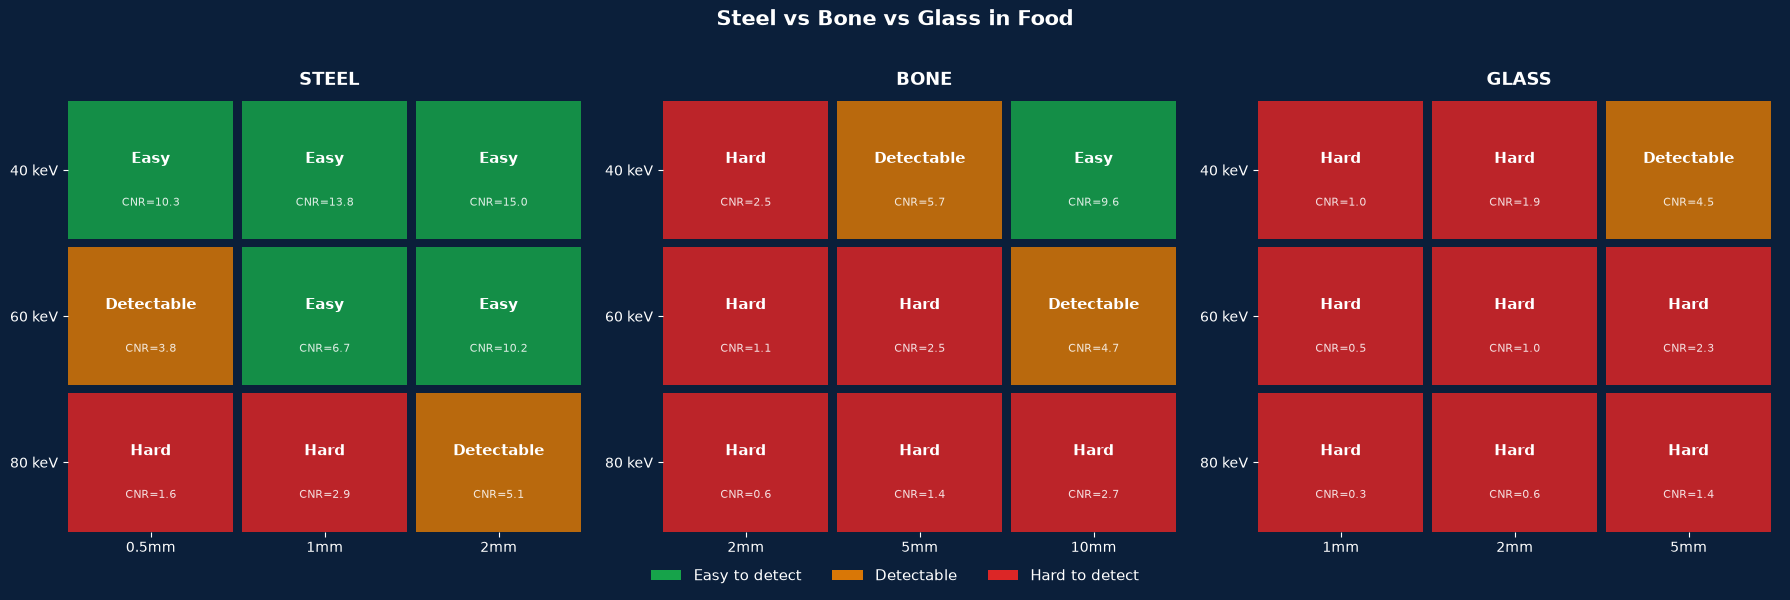

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/food_inspection_3material_simple.png


In [21]:
def detectability_label(cnr):
    if cnr >= 6:
        return "Easy", "#16A34A"
    elif cnr >= 3:
        return "Detectable", "#D97706"
    else:
        return "Hard", "#DC2626"

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.patch.set_facecolor("#0B1F3A")

for ax, (mat_name, mat_info) in zip(axes, MATERIALS.items()):
    ax.set_facecolor("#0B1F3A")
    mat_results = all_results[mat_name]
    thicks = mat_info["thicknesses"]

    for i, E in enumerate(ENERGIES):
        for j, T in enumerate(thicks):
            r = next((r for r in mat_results if r["energy"]==E and r["thickness"]==T), None)
            if r is None:
                continue
            label, color = detectability_label(r["cnr"])
            ax.add_patch(plt.Rectangle((j, len(ENERGIES)-1-i), 0.95, 0.95,
                                         facecolor=color, alpha=0.85))
            ax.text(j+0.475, len(ENERGIES)-1-i+0.55, label,
                    ha="center", va="center", color="white", fontsize=11, fontweight="bold")
            ax.text(j+0.475, len(ENERGIES)-1-i+0.25, f"CNR={r['cnr']:.1f}",
                    ha="center", va="center", color="white", fontsize=8, alpha=0.85)

    ax.set_xlim(0, len(thicks))
    ax.set_ylim(0, len(ENERGIES))
    ax.set_xticks([j+0.475 for j in range(len(thicks))])
    ax.set_xticklabels([mat_info["labels"][t] for t in thicks], color="white", fontsize=10)
    ax.set_yticks([len(ENERGIES)-1-i+0.475 for i in range(len(ENERGIES))])
    ax.set_yticklabels([f"{E} keV" for E in ENERGIES], color="white", fontsize=10)
    ax.set_title(mat_name.upper(), color="white", fontsize=13, fontweight="bold")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors="white")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#16A34A", label="Easy to detect"),
    Patch(facecolor="#D97706", label="Detectable"),
    Patch(facecolor="#DC2626", label="Hard to detect"),
]
fig.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=3, fontsize=11, facecolor="#0B1F3A", edgecolor="none", labelcolor="white")

fig.suptitle("Steel vs Bone vs Glass in Food",
             color="white", fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/food_inspection_3material_simple.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

In [22]:
# === Pd/FPR/ROC/AUC for all three materials ===

for mat_name, mat_results in all_results.items():
    for r in mat_results:
        mean_bg_roi = r["bg_n"] * ROI_FRACTION
        mean_c_roi = r["c_n"] * ROI_FRACTION

        thresholds = np.linspace(0, mean_bg_roi * 1.5, 200)
        pd_curve = poisson.cdf(thresholds, mean_c_roi)
        fpr_curve = poisson.cdf(thresholds, mean_bg_roi)

        order = np.argsort(fpr_curve)
        auc = trapezoid_area(pd_curve[order], fpr_curve[order])

        idx_5pct = np.argmin(np.abs(fpr_curve - 0.05))
        r["auc"] = auc
        r["pd_at_5pct_fpr"] = pd_curve[idx_5pct]

# Updated combined table including AUC
combined_rows = []
for mat_name, mat_results in all_results.items():
    for r in mat_results:
        combined_rows.append(r)

combined_df2 = pd.DataFrame(combined_rows)
full_summary = combined_df2[["material", "energy", "thickness_label",
                               "cnr", "auc", "pd_at_5pct_fpr"]].copy()
full_summary.columns = ["Material", "Energy (keV)", "Thickness", "CNR", "AUC", "Pd @ 5% FPR"]
full_summary = full_summary.round(3)
full_summary

,Material,Energy (keV),Thickness,CNR,AUC,Pd @ 5% FPR
0,steel,40,0.5mm,10.264,1.000,1.000
1,steel,40,1mm,13.780,1.000,1.000
2,steel,40,2mm,14.957,1.000,1.000
3,steel,60,0.5mm,3.828,0.997,0.988
4,steel,60,1mm,6.724,1.000,1.000
5,steel,60,2mm,10.219,1.000,1.000
6,steel,80,0.5mm,1.564,0.865,0.431
7,steel,80,1mm,2.917,0.981,0.889
8,steel,80,2mm,5.119,0.999,1.000
9,bone,40,2mm,2.515,0.963,0.799


In [23]:
# === Full pairwise separability matrix - background vs all 3 materials ===
# Using 60 keV as the common reference energy for fair comparison

REFERENCE_ENERGY = 60
REFERENCE_THICKNESS = {"steel": "1mm", "bone": "5mm", "glass": "2mm"}

# Gather one representative cluster_charge spectrum per class
class_spectra = {}
class_spectra["background"] = background_clusters[REFERENCE_ENERGY]["cluster_charge"][0]

for mat_name, mat_info in MATERIALS.items():
    T = REFERENCE_THICKNESS[mat_name]
    path = os.path.join(BASE, f"{mat_info['prefix']}_{REFERENCE_ENERGY}keV_{T}.root")
    _, cc = get_cluster_count(path)
    class_spectra[mat_name] = cc[0]

classes = list(class_spectra.keys())
n = len(classes)
sep_matrix = np.zeros((n, n))

for i, c1 in enumerate(classes):
    for j, c2 in enumerate(classes):
        sep_matrix[i, j] = bhattacharyya(class_spectra[c1], class_spectra[c2])

# Display as a table
sep_df = pd.DataFrame(sep_matrix, index=classes, columns=classes).round(3)
print(f"Pairwise Bhattacharyya separability matrix at {REFERENCE_ENERGY} keV")
print("(0 = identical/indistinguishable, higher = more separable)")
sep_df

Pairwise Bhattacharyya separability matrix at 60 keV
(0 = identical/indistinguishable, higher = more separable)


,background,steel,bone,glass
background,-0.000,0.008,0.002,0.000
steel,0.008,-0.000,0.006,0.007
bone,0.002,0.006,-0.000,0.001
glass,0.000,0.007,0.001,-0.000


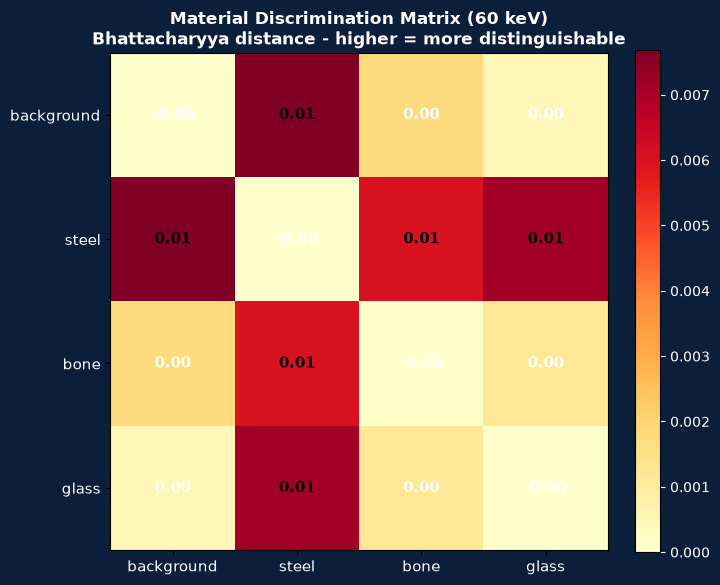

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/material_discrimination_matrix.png


In [24]:
# === Visualise as a heatmap ===
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0B1F3A")
ax.set_facecolor("#0B1F3A")

im = ax.imshow(sep_matrix, cmap="YlOrRd", vmin=0)
ax.set_xticks(range(n)); ax.set_xticklabels(classes, color="white", fontsize=11)
ax.set_yticks(range(n)); ax.set_yticklabels(classes, color="white", fontsize=11)

for i in range(n):
    for j in range(n):
        val = sep_matrix[i, j]
        color = "white" if val < sep_matrix.max()*0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color=color, fontsize=11, fontweight="bold")

ax.set_title(f"Material Discrimination Matrix ({REFERENCE_ENERGY} keV)\n"
              "Bhattacharyya distance - higher = more distinguishable",
              color="white", fontsize=12, fontweight="bold")
cbar = plt.colorbar(im, ax=ax, fraction=0.046)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

plt.tight_layout()
out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/material_discrimination_matrix.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")